# Spatial disaggregation

Disaggregate raster cells or vector geometries.

**_raster:_** Creates a raster with a higher resolution (smaller cells). The values in the new raster are the same as in the larger original cells.

**_vector:_** Separates multi-objects (points, lines, polygons) into single objects; or further into segments (for lines or polygons).

## Settings

In [12]:
# Load packages
suppressPackageStartupMessages({
  library(terra)
})

# Parameters
param_factor <- 10
param_method <- "bilinear" # or: "near" 
param_out <- tempdir()

# Paths for examples
in_raster <- system.file("ex/elev.tif", package = "terra")
in_vector <- system.file("ex/lux.shp", package = "terra")

## Disaggregate raster

In [ ]:
# GSTB disaggregate raster
# NaaVRE:
#  cell:
#   inputs:
#    - in_raster: String
#   params:
#    - param_factor: List
#    - param_method: String
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# File path to be disaggregated
x <- rast(in_raster)

# Disaggregate raster
disagg(x         = x,
       fact      = param_factor,
       method    = param_method,
       filename  = paste0(param_out, "/disaggregated_raster.tif"),
       overwrite = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "disaggregated_raster.tif",
                  full.names = TRUE)

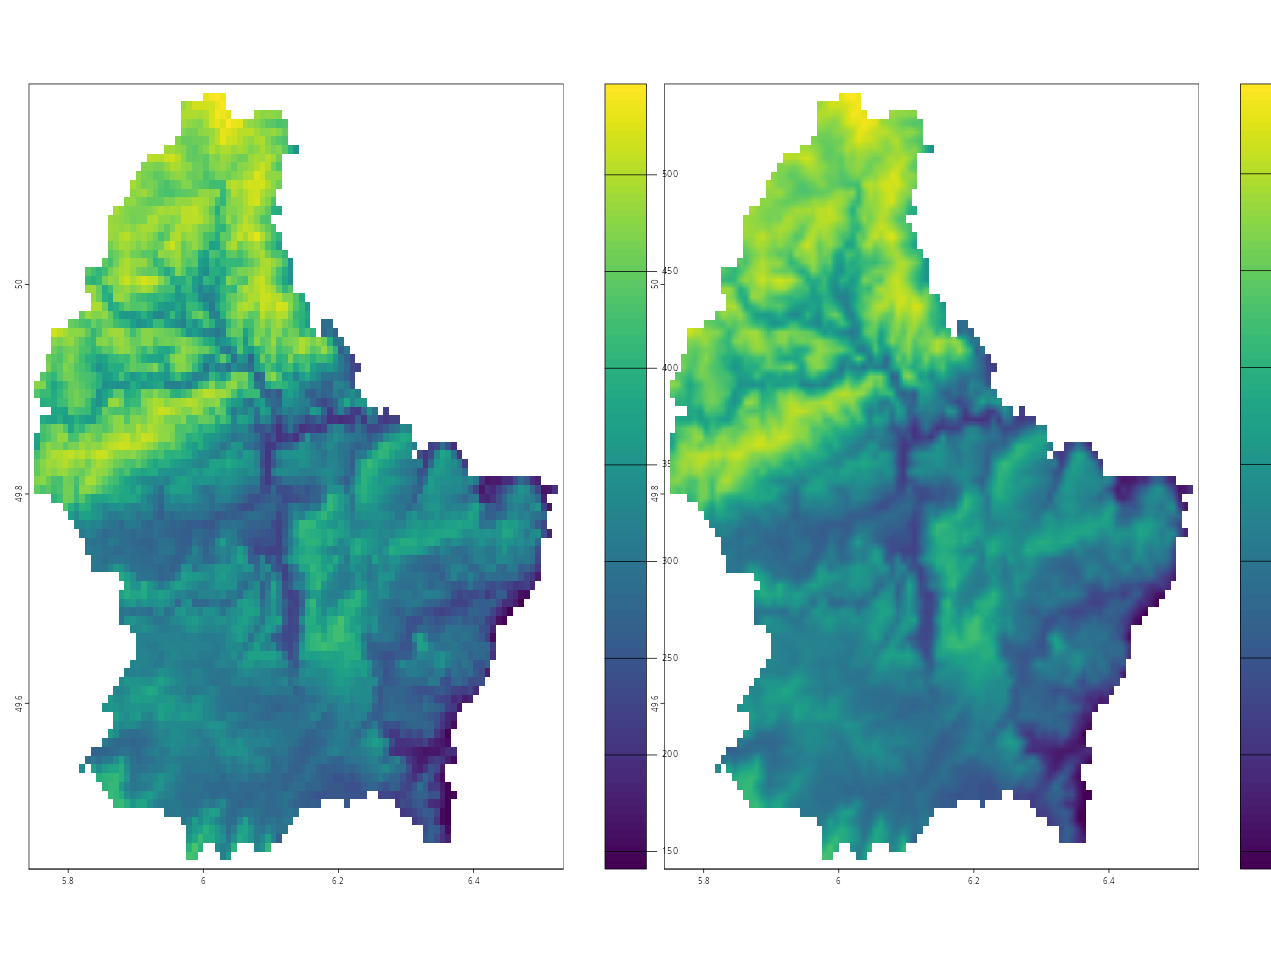

In [9]:
par(mfrow = c(1, 2))
plot(x)
plot(rast(out))
par(mfrow = c(1, 1))

## Disaggregate vector

In [19]:
# GSTB disaggregate vector
# NaaVRE:
#  cell:
#   inputs:
#    - in_vector: String
#   params:
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# File path to be disaggregated
x <- vect(in_vector)

# Disaggregate vector
v <- disagg(x        = x,
            segments = FALSE)
      
# Save to file
writeVector(x         = v,
            filename  = paste0(param_out, "/disaggregated_vector.gpkg"),
            overwrite = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "disaggregated_vector.gpkg",
                  full.names = TRUE)

In [20]:
print(vect(out))

 class       : SpatVector 
 geometry    : polygons 
 dimensions  : 12, 6  (geometries, attributes)
 extent      : 5.74414, 6.528252, 49.44781, 50.18162  (xmin, xmax, ymin, ymax)
 source      : disaggregated_vector.gpkg
 coord. ref. : lon/lat WGS 84 (EPSG:4326) 
 names       :  ID_1   NAME_1  ID_2   NAME_2  AREA       POP
 type        : <num>    <chr> <num>    <chr> <num>     <num>
 values      :     1 Diekirch     1 Clervaux   312 1.808e+04
                   1 Diekirch     2 Diekirch   218 3.254e+04
                   1 Diekirch     3  Redange   259 1.866e+04


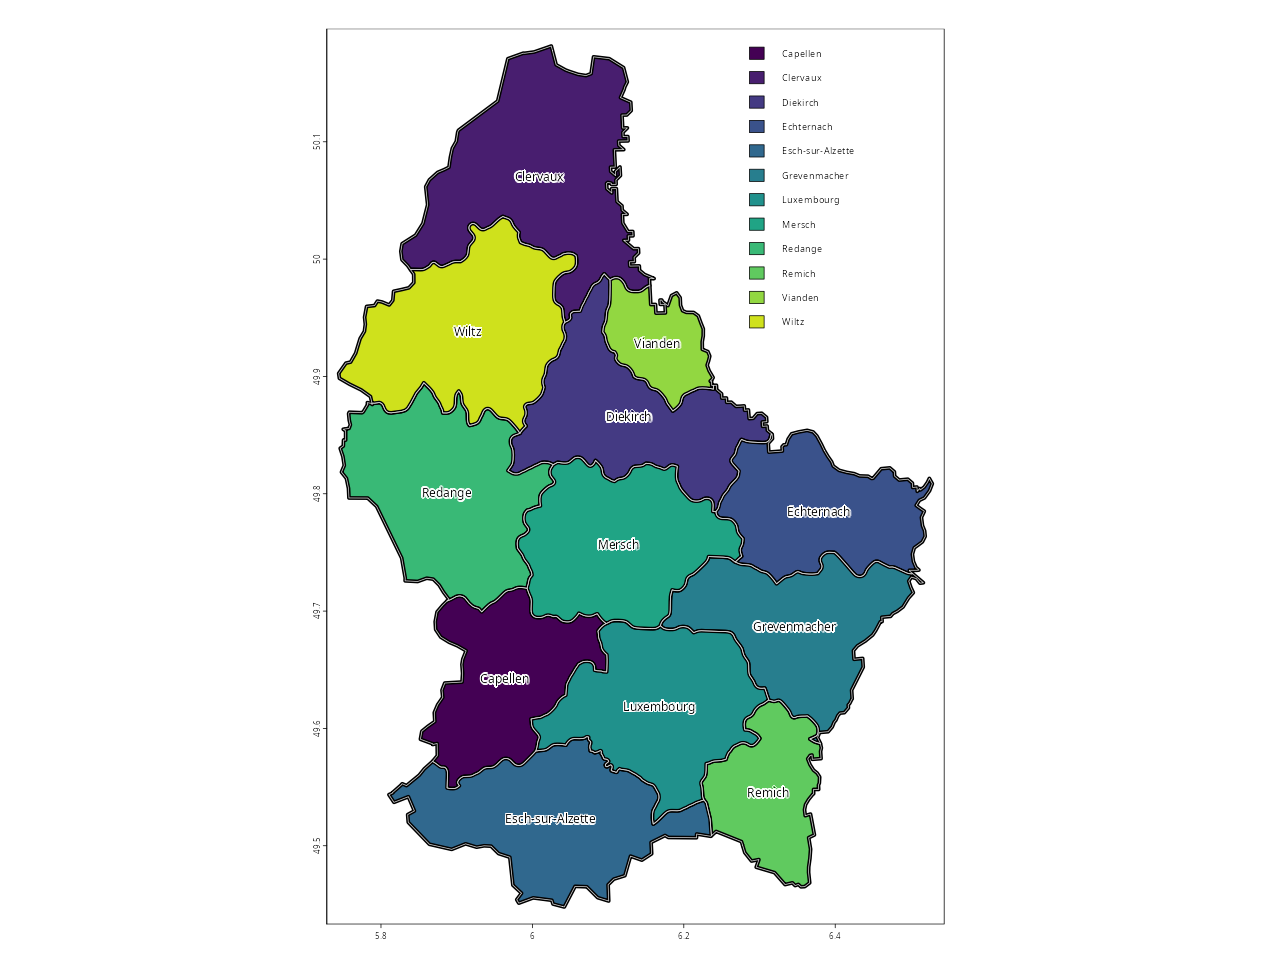

In [21]:
plot(vect(out), "NAME_2", lwd = 5, plg = list(x = "topright"), mar = rep(2, 4))
lines(x, lwd = 1, col = "light gray")
text(v, "NAME_2", halo = TRUE)